In [1]:
import pandas               as pd
import numpy                as np
import matplotlib.pyplot     as plt
import warnings
warnings.filterwarnings('ignore')

Tập tin ‘titanic-seaborn.xls’ lưu trữ số liệu về hành khách trên chuyến tàu Titanic (04/1912), gồm có các sheets: “Passengers” (khóa nội passengerID) và “Sinking”.

In [2]:
df_passengers = pd.read_excel('titanic-seaborn.xls', sheet_name='Passengers')
df_sinking = pd.read_excel('titanic-seaborn.xls', sheet_name='Sinking')

print(df_passengers.info())
print(df_sinking.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerID  891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
dtypes: bool(1), float64(2), int64(4), str(6)
memory usage: 84.5 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   passengerID  891 non-null

In [3]:
df = df_passengers.merge(df_sinking, on='passengerID', how='inner')
df

,passengerID,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,survived,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,0,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,1,yes,False
2,2,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,1,yes,True
3,3,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,1,yes,False
4,4,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,0,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,886,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,0,no,True
887,887,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,1,yes,True
888,888,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,0,no,False
889,889,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,1,yes,True


1.1) Liệt kê những hành khách (passengerID, age, sex) thuộc hạng vé (pclass hoặc class) được chỉ định từ một giá trị được nhập từ bàn phím (cho phép nhập nhiều lần).

In [4]:
# Minh họa: giả lập lần lượt nhập "1", "3" rồi Enter để dừng
_demo = iter(['1', '3', ''])
input = lambda prompt='': next(_demo)

while True:
    hang_ve = input('Nhập hạng vé cần tra cứu (Enter để dừng): ')
    if hang_ve == '':
        break
    print(df.loc[df['pclass'] == int(hang_ve), ['passengerID', 'age', 'sex']])

     passengerID   age     sex
1              1  38.0  female
3              3  35.0  female
6              6  54.0    male
11            11  58.0  female
23            23  28.0    male
..           ...   ...     ...
871          871  47.0  female
872          872  33.0    male
879          879  56.0  female
887          887  19.0  female
889          889  26.0    male

[216 rows x 3 columns]
     passengerID   age     sex
0              0  22.0    male
2              2  26.0  female
4              4  35.0    male
5              5   NaN    male
7              7   2.0    male
..           ...   ...     ...
882          882  22.0  female
884          884  25.0    male
885          885  39.0  female
888          888   NaN  female
890          890  32.0    male

[491 rows x 3 columns]


1.2) Cho biết độ tuổi trung bình và độ lệch chuẩn của những nữ hành khách đi vé hạng 3.

In [5]:
nu_hang3 = df[(df['sex'] == 'female') & (df['pclass'] == 3)]
print('Tuổi trung bình:', nu_hang3['age'].mean())
print('Độ lệch chuẩn:', nu_hang3['age'].std())

Tuổi trung bình: 21.75
Độ lệch chuẩn: 12.729963872612515


1.3) Cho biết tổng số tiền vé tàu (fare) của từng địa điểm nhận khách lên tàu (embark_town).

In [6]:
df.groupby('embark_town')['fare'].sum()

embark_town
Cherbourg      10072.2962
Queenstown      1022.2543
Southampton    17439.3988
Name: fare, dtype: float64

1.4) Cho biết những hạng vé có tổng số tiền vé lớn hơn 5000.

In [7]:
tong_fare = df.groupby('pclass')['fare'].sum()
tong_fare[tong_fare > 5000]

pclass
1    18177.4125
3     6714.6951
Name: fare, dtype: float64

1.5) Cho biết địa điểm có hành khách lên tàu nhiều nhất.

In [8]:
df['embark_town'].value_counts().idxmax()

'Southampton'

1.6) Cho biết tổng số nữ hành khách theo từng độ tuổi: 0-12, 13-18, 19-45, 46-64, 65+.

In [9]:
khoang_tuoi = [0, 12, 18, 45, 64, 150]
nhan_tuoi = ['0-12', '13-18', '19-45', '46-64', '65+']
df['nhom_tuoi'] = pd.cut(df['age'], bins=khoang_tuoi, labels=nhan_tuoi)

df[df['sex'] == 'female']['nhom_tuoi'].value_counts().reindex(nhan_tuoi)

nhom_tuoi
0-12      32
13-18     36
19-45    163
46-64     30
65+        0
Name: count, dtype: int64

1.7) Cho biết những hành khách vẫn còn đang sống ở thời điểm thống kê số liệu.

In [10]:
df[df['alive'] == 'yes']

,passengerID,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,survived,alive,alone,nhom_tuoi
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,1,yes,False,19-45
2,2,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,1,yes,True,19-45
3,3,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,1,yes,False,19-45
8,8,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,1,yes,False,19-45
9,9,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,1,yes,False,13-18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875,875,3,female,15.0,0,0,7.2250,C,Third,child,False,NaN,Cherbourg,1,yes,True,13-18
879,879,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,1,yes,False,46-64
880,880,2,female,25.0,0,1,26.0000,S,Second,woman,False,NaN,Southampton,1,yes,False,19-45
887,887,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,1,yes,True,19-45


1.8) Tạo bảng tổng hợp dữ liệu những hành khách sống sót trong tai nạn theo mẫu (hàng: Có gia đình / Độc thân, cột: Vé hạng 1/2/3, Tổng cộng).

In [11]:
bang = pd.pivot_table(df[df['survived'] == 1], index='alone', columns='pclass',
                       values='passengerID', aggfunc='count', fill_value=0,
                       margins=True, margins_name='Tổng cộng')
bang.index = [{False: 'Có gia đình', True: 'Độc thân', 'Tổng cộng': 'Tổng cộng'}[i] for i in bang.index]
bang.columns = [f'Vé hạng {c}' if c != 'Tổng cộng' else c for c in bang.columns]
bang

,Vé hạng 1,Vé hạng 2,Vé hạng 3,Tổng cộng
Có gia đình,78,51,50,179
Độc thân,58,36,69,163
Tổng cộng,136,87,119,342


2.1) Vẽ biểu đồ thể hiện tổng số hành khách theo hạng vé.

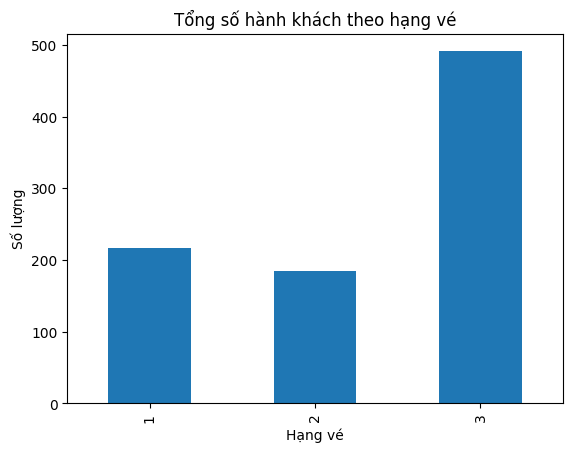

In [12]:
df['pclass'].value_counts().sort_index().plot(kind='bar', title='Tổng số hành khách theo hạng vé')
plt.xlabel('Hạng vé')
plt.ylabel('Số lượng')
plt.show()

2.2) Vẽ biểu đồ tỷ lệ % hành khách tử nạn theo độ tuổi: 0-12, 13-18, 19-45, 46-64, 65+.

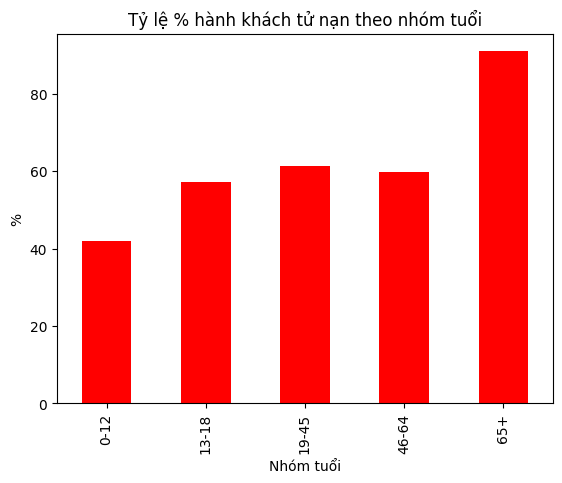

In [13]:
tong = df.groupby('nhom_tuoi', observed=False)['passengerID'].count()
tu_nan = df[df['survived'] == 0].groupby('nhom_tuoi', observed=False)['passengerID'].count()
ty_le = (tu_nan / tong * 100).round(2)

ty_le.plot(kind='bar', color='red', title='Tỷ lệ % hành khách tử nạn theo nhóm tuổi')
plt.xlabel('Nhóm tuổi')
plt.ylabel('%')
plt.show()